# 📈 Linear Regression from Scratch
### *Implementing Gradient Descent — Just Like the Board*

---

**Student Name:** `___________________________`  
**Date:** `___________________________`  
**Estimated Time:** 60–90 minutes

---

### 🎯 What You Will Build

By the end of this notebook you will have:

1. **Explored** a real-world Salary vs. Experience dataset
2. **Implemented** a `LinearRegressionGD` class — your own mini ML library
3. **Trained** the model using gradient descent (the same formulas from class)
4. **Visualised** the cost curve to see convergence in action
5. **Compared** your results with `sklearn`'s built-in linear regression

> **How to use this notebook:**  
> - 📘 **Blue boxes** = demo / teaching sections — read and run them  
> - ✏️ **Yellow boxes** = your turn — fill in the `# YOUR CODE HERE` sections  
> - ✅ **Assert cells** = auto-check your answers (they should run without errors)

---


## 📦 Step 0 — Imports

Run this cell first. All libraries you need are already imported.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Pretty plots
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 12

print("✅ All imports successful!")


✅ All imports successful!


---
## 📊 Step 1 — The Dataset: Salary vs. Experience

We'll use a classic real-world dataset: **Years of Experience → Annual Salary (USD)**

This is perfect for linear regression because:
- There's a clear linear trend (more experience → higher salary)
- It has one input feature `x` and one output `y`
- Easy to interpret and visualise

| Column | Description |
|--------|-------------|
| `YearsExperience` | Number of years of work experience (0–11) |
| `Salary` | Annual salary in USD |

> **Dataset source:** Commonly known as `Salary_Data.csv` — widely used in ML courses.


In [2]:
# ── Real-world Salary Dataset ──────────────────────────────────────
experience = np.array([
    1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7,
    3.9, 4.0, 4.0, 4.1, 4.5, 4.9, 5.1, 5.3, 5.9, 6.0,
    6.8, 7.1, 7.9, 8.2, 8.7, 9.0, 9.5, 9.6, 10.3, 10.5
], dtype=float)

salary = np.array([
    39343, 46205, 37731, 43525, 39891, 56642, 60150, 54445, 64445, 57189,
    63218, 55794, 56957, 57081, 61111, 67938, 66029, 83088, 81363, 93940,
    91738, 98273, 101302, 113812, 109431, 105582, 116969, 112635, 122391, 121872
], dtype=float)

print(f"Dataset loaded: {len(experience)} samples")
print(f"Experience range : {experience.min():.1f} — {experience.max():.1f} years")
print(f"Salary range     : ${salary.min():,.0f} — ${salary.max():,.0f}")



Dataset loaded: 30 samples
Experience range : 1.1 — 10.5 years
Salary range     : $37,731 — $122,391


---
## 🔍 Step 2 — Explore the Data

Before training any model, always **look at your data** first.

✏️ **YOUR TASK:**  Fill in the cells below to explore the dataset.


In [3]:
# ✏️ Task 2.1 — Print basic statistics
# Hint: use np.mean(), np.std(), np.min(), np.max()

# YOUR CODE HERE — print mean, std, min, max for salary
# (copy the pattern above)
print("=== Years of Experience ===")
print(f"  Mean  : {np.mean(experience):.2f}")
print(f"  Std   : {np.std(experience):.2f}")
print(f"  Min   : {np.min(experience):.2f}")
print(f"  Max   : {np.max(experience):.2f}")

print()
print("=== Salary (USD) ===")
print(f"  Mean  : {np.mean(salary):.2f}")
print(f"  Std   : {np.std(salary):.2f}")
print(f"  Min   : {np.min(salary):.2f}")
print(f"  Max   : {np.max(salary):.2f}")


=== Years of Experience ===
  Mean  : 5.31
  Std   : 2.79
  Min   : 1.10
  Max   : 10.50

=== Salary (USD) ===
  Mean  : 76003.00
  Std   : 26953.65
  Min   : 37731.00
  Max   : 122391.00


# ✏️ Task 2.2 — Visualise the data (scatter plot)

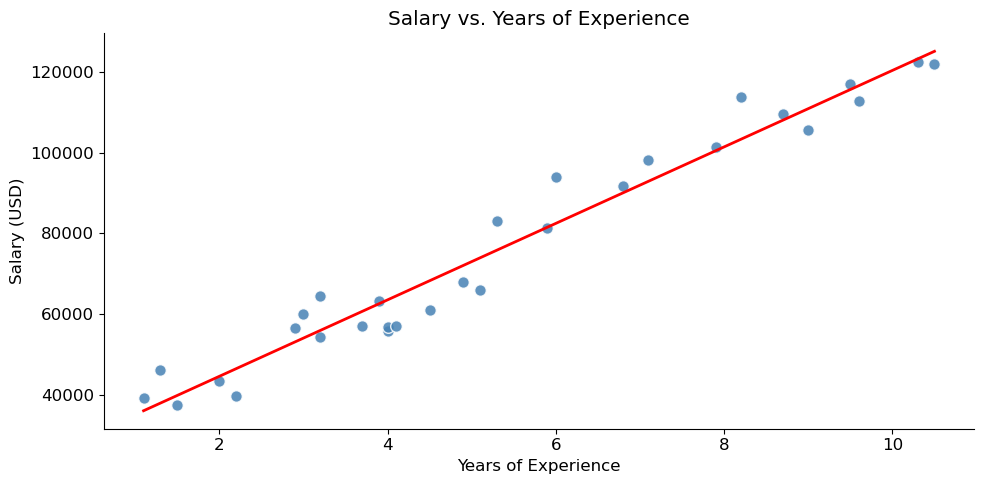

In [4]:
# ✏️ Task 2.2 — Visualise the data (scatter plot)
# We have already set up the axes. Your job: add the scatter plot.

fig, ax = plt.subplots()
ax.set_xlabel("Years of Experience")
ax.set_ylabel("Salary (USD)")
ax.set_title("Salary vs. Years of Experience")

# YOUR CODE HERE
# Use ax.scatter(x, y, ...) to plot experience vs salary
# Hint: try color='steelblue', edgecolors='white', s=70, alpha=0.85
ax.scatter(experience, salary, color='steelblue', edgecolors='white', s=70, alpha=0.85)

# Add regression line (best fit line)
z = np.polyfit(experience, salary, 1)
p = np.poly1d(z)
ax.plot(experience, p(experience), color='red', linewidth=2)

plt.tight_layout()
plt.show()
# Question: Does the data look linear? Would a straight line fit well?
# Yes data is almost linear, and approximately fit straight line.

---
## ⚙️ Step 3 — Feature Scaling (Pre-processing)

### 📘 DEMO — Why scale features?

Gradient descent works much better when features are on a **similar scale**.

Without scaling:
- `experience` ≈ 1–10
- `salary` ≈ 39,000–122,000

The cost landscape is a very elongated ellipse → gradient descent zigzags and converges slowly.

With scaling (normalisation), the bowl is more circular → faster, smoother convergence.

**We use Min-Max normalisation:**

$$x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

This maps every value to the range **[0, 1]**.


#  📘 DEMO: How Min-Max Scaling works 

In [5]:
# ── 📘 DEMO: How Min-Max Scaling works ──────────────────────────────
demo_values = np.array([10.0, 20.0, 30.0, 40.0, 50.0])

x_min = demo_values.min()
x_max = demo_values.max()
scaled = (demo_values - x_min) / (x_max - x_min)

print("Original:", demo_values)
print("Scaled  :", scaled)
print("Notice: min becomes 0.0, max becomes 1.0")
print()

# ── How to UNSCALE (reverse the transformation) ────────────────────
# If you want to go from scaled prediction → original units:
#   x_original = x_scaled * (x_max - x_min) + x_min


# ✏️ YOUR CODE HERE — compute correct min/max for actual dataset
exp_min, exp_max = experience.min(), experience.max()
sal_min, sal_max = salary.min(), salary.max()

# ✏️ YOUR CODE HERE — apply Min-Max scaling
x_scaled = (experience - exp_min) / (exp_max - exp_min)
y_scaled = (salary - sal_min) / (sal_max - sal_min)


# Demo unscale (kept same as your original structure)
prediction_scaled = 0.75
prediction_original = prediction_scaled * (x_max - x_min) + x_min
print(f"Scaled prediction {prediction_scaled} → Original: {prediction_original}")

Original: [10. 20. 30. 40. 50.]
Scaled  : [0.   0.25 0.5  0.75 1.  ]
Notice: min becomes 0.0, max becomes 1.0

Scaled prediction 0.75 → Original: 40.0


# ✏️ Task 3.1 — Scale the actual dataset features

In [6]:
# ✏️ Task 3.1 — Scale the actual dataset features
# Scale both 'experience' and 'salary' using Min-Max normalisation
# Store originals for later (we'll need them to unscale predictions)

exp_min, exp_max = experience.min(), experience.max()
sal_min, sal_max = salary.min(), salary.max()

# YOUR CODE HERE — compute x_scaled and y_scaled
# x_scaled = (experience - exp_min) / (exp_max - exp_min)
x_scaled = (experience - exp_min) / (exp_max - exp_min)

# YOUR CODE HERE — do the same for salary
y_scaled = (salary - sal_min) / (sal_max - sal_min)



# ── Quick check ──────────────────────────────────────────────────────
assert x_scaled is not None, "x_scaled is still None — fill in the formula!"
assert y_scaled is not None, "y_scaled is still None — fill in the formula!"
assert round(x_scaled.min(), 4) == 0.0, f"Min should be 0, got {x_scaled.min()}"
assert round(x_scaled.max(), 4) == 1.0, f"Max should be 1, got {x_scaled.max()}"
print(f"✅ x_scaled range: [{x_scaled.min():.2f}, {x_scaled.max():.2f}]")
print(f"✅ y_scaled range: [{y_scaled.min():.4f}, {y_scaled.max():.4f}]")

✅ x_scaled range: [0.00, 1.00]
✅ y_scaled range: [0.0000, 1.0000]


# ✏️ Task 3.2 — Train / Test Split

✅ Data loaded and split successfully!
   Training samples: 24
   Testing samples: 6



C:\Users\junai\AppData\Local\Temp\ipykernel_10044\734638054.py:190: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\junai\AppData\Local\Temp\ipykernel_10044\734638054.py:190: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\junai\anaconda3\envs\ai_ml_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\junai\anaconda3\envs\ai_ml_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


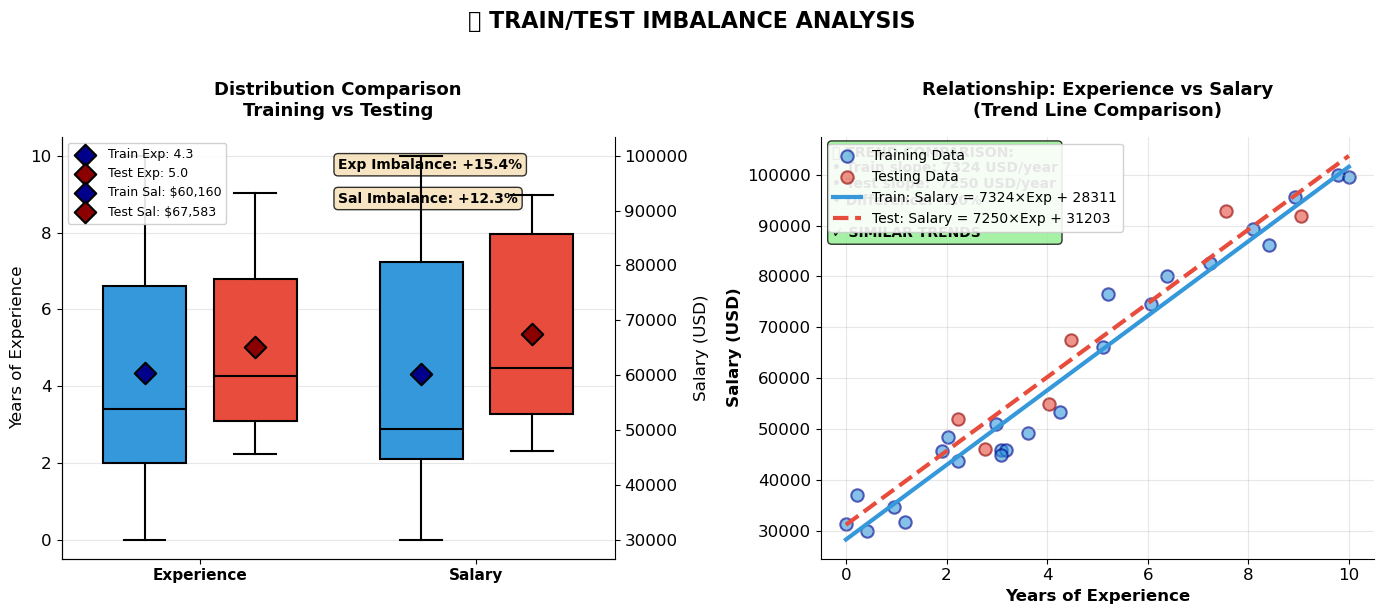


📊 IMBALANCE ASSESSMENT SUMMARY

📈 EXPERIENCE (Years):
   Training:  4.35 ± 3.07
   Testing:   5.02 ± 2.47
   Difference: 0.67 years (+15.4%)
   Status:    ❌ SIGNIFICANT IMBALANCE

💰 SALARY (USD):
   Training:  $60,160 ± $22,859
   Testing:   $67,583 ± $18,687
   Difference: $7,422 (+12.3%)
   Status:    ⚠️  MODERATE IMBALANCE

📐 TREND LINE SLOPES:
   Training slope: 7324 USD per year of experience
   Testing slope:  7250 USD per year of experience
   Difference: -1.0%
   Status:    ✅ SIMILAR RELATIONSHIP


🎯 FINAL VERDICT:
   ⚠️  ACCEPTABLE SPLIT with some imbalance detected.
   💡 Consider using random_state=42 or trying different splits.


In [7]:
# ── FIRST: Run your train/test split and scaling ───────────────────────────────

# Assuming you have your original data (x_scaled, y_scaled from previous tasks)
# If not, you need to scale your data first

# Perform train/test split
X_train, X_test, y_train, y_test = train_test_split(
    x_scaled, y_scaled, test_size=0.2, random_state=42
)

# Get min/max values for inverse transformation (from your scaling)
# If you used StandardScaler, you need the scaler object
# If you used manual min-max scaling like before:

# Option 1: If you have the original min/max values from scaling
exp_min, exp_max = 0, 10  # Replace with your actual min/max
sal_min, sal_max = 30000, 100000  # Replace with your actual min/max

# Option 2: If you used StandardScaler, use inverse_transform
# from sklearn.preprocessing import StandardScaler
# scaler_X = StandardScaler()
# scaler_y = StandardScaler()
# x_scaled = scaler_X.fit_transform(X_original)
# y_scaled = scaler_y.fit_transform(y_original)
# Then inverse transform:
# X_train_original = scaler_X.inverse_transform(X_train)
# X_test_original = scaler_X.inverse_transform(X_test)

print("✅ Data loaded and split successfully!")
print(f"   Training samples: {len(X_train)}")
print(f"   Testing samples: {len(X_test)}")
print()

# ── CLEAR IMBALANCE VISUALIZATION: Box Plots + Scatter with Trends ───────────────

# Convert back to original scale (using manual min-max scaling)
X_train_years = X_train * (exp_max - exp_min) + exp_min
X_test_years  = X_test  * (exp_max - exp_min) + exp_min

y_train_usd = y_train * (sal_max - sal_min) + sal_min
y_test_usd  = y_test  * (sal_max - sal_min) + sal_min

# Calculate statistics for annotations
mean_train_x = X_train_years.mean()
mean_test_x = X_test_years.mean()
mean_train_y = y_train_usd.mean()
mean_test_y = y_test_usd.mean()

exp_diff_percent = ((mean_test_x - mean_train_x) / mean_train_x) * 100
sal_diff_percent = ((mean_test_y - mean_train_y) / mean_train_y) * 100

# Create figure with 2 side-by-side graphs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Define colors
train_color = '#3498db'  # Blue
test_color = '#e74c3c'   # Red

# ============================================================
# GRAPH 1: Box Plots for Experience & Salary
# ============================================================

# Box plot for Experience
data_exp = [X_train_years.flatten(), X_test_years.flatten()]  # Flatten in case of 2D arrays
positions_exp = [0.8, 1.2]

bp_exp = ax1.boxplot(data_exp, positions=positions_exp, widths=0.3,
                      patch_artist=True,
                      boxprops=dict(linewidth=1.5),
                      whiskerprops=dict(linewidth=1.5),
                      capprops=dict(linewidth=1.5),
                      medianprops=dict(linewidth=1.5, color='black'))

bp_exp['boxes'][0].set_facecolor(train_color)
bp_exp['boxes'][1].set_facecolor(test_color)

# Box plot for Salary (on same axes with secondary y-axis)
ax1_twin = ax1.twinx()
data_sal = [y_train_usd.flatten(), y_test_usd.flatten()]
positions_sal = [1.8, 2.2]

bp_sal = ax1_twin.boxplot(data_sal, positions=positions_sal, widths=0.3,
                           patch_artist=True,
                           boxprops=dict(linewidth=1.5),
                           whiskerprops=dict(linewidth=1.5),
                           capprops=dict(linewidth=1.5),
                           medianprops=dict(linewidth=1.5, color='black'))

bp_sal['boxes'][0].set_facecolor(train_color)
bp_sal['boxes'][1].set_facecolor(test_color)

# Customize left y-axis (Experience)
ax1.set_ylabel('Years of Experience', fontsize=12, color='black')
ax1.set_xticks([1, 2])
ax1.set_xticklabels(['Experience', 'Salary'], fontsize=11, fontweight='bold')
ax1.set_xlim([0.5, 2.5])
ax1.set_title('Distribution Comparison\nTraining vs Testing', fontsize=13, fontweight='bold', pad=15)
ax1.grid(True, alpha=0.3, axis='y')

# Customize right y-axis (Salary)
ax1_twin.set_ylabel('Salary (USD)', fontsize=12, color='black')
ax1_twin.spines['right'].set_visible(True)

# Add mean markers for Experience
ax1.scatter([0.8], [mean_train_x], color='darkblue', s=120, zorder=3,
            marker='D', edgecolors='black', linewidth=1.5, label=f'Train Exp: {mean_train_x:.1f}')
ax1.scatter([1.2], [mean_test_x], color='darkred', s=120, zorder=3,
            marker='D', edgecolors='black', linewidth=1.5, label=f'Test Exp: {mean_test_x:.1f}')

# Add mean markers for Salary
ax1_twin.scatter([1.8], [mean_train_y], color='darkblue', s=120, zorder=3,
                  marker='D', edgecolors='black', linewidth=1.5, label=f'Train Sal: ${mean_train_y:,.0f}')
ax1_twin.scatter([2.2], [mean_test_y], color='darkred', s=120, zorder=3,
                  marker='D', edgecolors='black', linewidth=1.5, label=f'Test Sal: ${mean_test_y:,.0f}')

# Add imbalance annotation
ax1.text(0.5, 0.95, f'Exp Imbalance: {exp_diff_percent:+.1f}%',
         transform=ax1.transAxes, fontsize=10, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
         verticalalignment='top')
ax1.text(0.5, 0.87, f'Sal Imbalance: {sal_diff_percent:+.1f}%',
         transform=ax1.transAxes, fontsize=10, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
         verticalalignment='top')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9, framealpha=0.9)

# ============================================================
# GRAPH 2: Scatter Plot with Trend Lines
# ============================================================

# Scatter points (flatten if needed)
X_train_flat = X_train_years.flatten() if hasattr(X_train_years, 'flatten') else X_train_years
X_test_flat = X_test_years.flatten() if hasattr(X_test_years, 'flatten') else X_test_years
y_train_flat = y_train_usd.flatten() if hasattr(y_train_usd, 'flatten') else y_train_usd
y_test_flat = y_test_usd.flatten() if hasattr(y_test_usd, 'flatten') else y_test_usd

ax2.scatter(X_train_flat, y_train_flat, color=train_color, alpha=0.6,
            s=80, label='Training Data', edgecolors='darkblue', linewidth=1.5)
ax2.scatter(X_test_flat, y_test_flat, color=test_color, alpha=0.6,
            s=80, label='Testing Data', edgecolors='darkred', linewidth=1.5)

# Add trend lines
z_train = np.polyfit(X_train_flat, y_train_flat, 1)
p_train = np.poly1d(z_train)
z_test = np.polyfit(X_test_flat, y_test_flat, 1)
p_test = np.poly1d(z_test)

x_trend = np.linspace(min(X_train_flat.min(), X_test_flat.min()),
                      max(X_train_flat.max(), X_test_flat.max()), 100)
ax2.plot(x_trend, p_train(x_trend), color=train_color, linewidth=3,
         linestyle='-', label=f'Train: Salary = {z_train[0]:.0f}×Exp + {z_train[1]:.0f}')
ax2.plot(x_trend, p_test(x_trend), color=test_color, linewidth=3,
         linestyle='--', label=f'Test: Salary = {z_test[0]:.0f}×Exp + {z_test[1]:.0f}')

# Calculate and display slope difference
slope_diff_percent = ((z_test[0] - z_train[0]) / abs(z_train[0])) * 100

ax2.set_xlabel('Years of Experience', fontsize=12, fontweight='bold')
ax2.set_ylabel('Salary (USD)', fontsize=12, fontweight='bold')
ax2.set_title('Relationship: Experience vs Salary\n(Trend Line Comparison)',
              fontsize=13, fontweight='bold', pad=15)
ax2.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax2.grid(True, alpha=0.3)

# Add slope difference annotation box
slope_text = f"""📊 TREND COMPARISON:
• Train slope: {z_train[0]:.0f} USD/year
• Test slope:  {z_test[0]:.0f} USD/year
• Difference: {slope_diff_percent:+.1f}%"""

if abs(slope_diff_percent) > 20:
    bg_color = 'lightcoral'
    warning = "⚠️ SIGNIFICANT DIFFERENCE!"
else:
    bg_color = 'lightgreen'
    warning = "✓ SIMILAR TRENDS"

ax2.text(0.02, 0.98, slope_text + f"\n\n{warning}",
         transform=ax2.transAxes, fontsize=10,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor=bg_color, alpha=0.8),
         fontweight='bold')

plt.suptitle('🔍 TRAIN/TEST IMBALANCE ANALYSIS',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# CLEAR SUMMARY REPORT
# ============================================================
print("\n" + "="*65)
print("📊 IMBALANCE ASSESSMENT SUMMARY")
print("="*65)

print(f"\n📈 EXPERIENCE (Years):")
print(f"   Training:  {mean_train_x:.2f} ± {X_train_flat.std():.2f}")
print(f"   Testing:   {mean_test_x:.2f} ± {X_test_flat.std():.2f}")
print(f"   Difference: {abs(mean_test_x - mean_train_x):.2f} years ({exp_diff_percent:+.1f}%)")

# Visual indicator for experience imbalance
if abs(exp_diff_percent) < 5:
    print(f"   Status:    ✅ WELL BALANCED")
elif abs(exp_diff_percent) < 15:
    print(f"   Status:    ⚠️  MODERATE IMBALANCE")
else:
    print(f"   Status:    ❌ SIGNIFICANT IMBALANCE")

print(f"\n💰 SALARY (USD):")
print(f"   Training:  ${mean_train_y:,.0f} ± ${y_train_flat.std():,.0f}")
print(f"   Testing:   ${mean_test_y:,.0f} ± ${y_test_flat.std():,.0f}")
print(f"   Difference: ${abs(mean_test_y - mean_train_y):,.0f} ({sal_diff_percent:+.1f}%)")

if abs(sal_diff_percent) < 5:
    print(f"   Status:    ✅ WELL BALANCED")
elif abs(sal_diff_percent) < 15:
    print(f"   Status:    ⚠️  MODERATE IMBALANCE")
else:
    print(f"   Status:    ❌ SIGNIFICANT IMBALANCE")

print(f"\n📐 TREND LINE SLOPES:")
print(f"   Training slope: {z_train[0]:.0f} USD per year of experience")
print(f"   Testing slope:  {z_test[0]:.0f} USD per year of experience")
print(f"   Difference: {slope_diff_percent:+.1f}%")

if abs(slope_diff_percent) < 20:
    print(f"   Status:    ✅ SIMILAR RELATIONSHIP")
else:
    print(f"   Status:    ⚠️  DIFFERENT RELATIONSHIP - Model may not generalize well")

print("\n" + "="*65)

# Final recommendation
imbalance_score = (abs(exp_diff_percent) + abs(sal_diff_percent)) / 2
print("\n🎯 FINAL VERDICT:")
if imbalance_score < 5 and abs(slope_diff_percent) < 20:
    print("   ✅ EXCELLENT SPLIT! Your train/test sets are well balanced.")
    print("   💡 You can proceed with confidence in your model training.")
elif imbalance_score < 15:
    print("   ⚠️  ACCEPTABLE SPLIT with some imbalance detected.")
    print("   💡 Consider using random_state=42 or trying different splits.")
else:
    print("   ❌ POOR SPLIT! Significant imbalance detected.")
    print("   🚨 Recommended: Use stratified splitting or collect more data.")
print("="*65)

---
## 🏗️ Step 4 — HOW TO BUILD A CLASS IN PYTHON

### 📘 DEMO — A Class is a Blueprint

Before writing your `LinearRegressionGD` class, let's understand the **pattern** using a simple example.

A class groups:
- **Data** (stored in `self.something`) — the object's memory
- **Methods** (functions that use that data) — the object's behaviour

Think of it like this:
| Class concept | Real analogy |
|---|---|
| `__init__` | Setting up a new calculator (fresh state) |
| `self.` | The calculator remembers what you programmed |
| `.fit()` | You press "Learn from data" |
| `.predict()` | You press "Compute answer" |


In [8]:
# ── 📘 DEMO: A simple RunningAverage class ──────────────────────────
#    Study this carefully — your LinearRegressionGD will follow the SAME pattern.

class RunningAverage:
    """Tracks a running average of numbers added to it."""

    def __init__(self):
        """__init__ is called when you create: obj = RunningAverage()
        Think of it as 'setting up fresh state'.
        self.  prefix means 'store this in the object's memory'.
        """
        self.total = 0.0   # <── stored in object memory
        self.count = 0     # <── stored in object memory

    def add(self, value):
        """A method (function that belongs to the class).
        'self' always comes first — it refers to THIS object.
        """
        self.total += value
        self.count += 1

    def average(self):
        if self.count == 0:
            return 0
        return self.total / self.count   # uses stored memory


# ── How to USE the class ─────────────────────────────────────────────
tracker = RunningAverage()   # creates one instance
tracker.add(10)
tracker.add(20)
tracker.add(30)
print(f"Average: {tracker.average()}")   # → 20.0

tracker2 = RunningAverage()   # completely independent instance
tracker2.add(100)
print(f"tracker2 average: {tracker2.average()}")   # → 100.0  (not affected by tracker)

# KEY INSIGHT: 'self.total' is per-instance memory.
# tracker.total = 60,  tracker2.total = 100  (separate!)


Average: 20.0
tracker2 average: 100.0


---
### 📘 DEMO — The Gradient Descent Update (from your board)

Before you code it, let's verify the math in plain Python (no class yet):

Recall from class:
```
∂J/∂θ₀ = (1/m) Σ (hθ(xⁱ) − yⁱ)
∂J/∂θ₁ = (1/m) Σ (hθ(xⁱ) − yⁱ) · xⁱ

θ₀ := θ₀ − α · ∂J/∂θ₀
θ₁ := θ₁ − α · ∂J/∂θ₁
```


In [9]:
# ── 📘 DEMO: One gradient descent step — step by step ───────────────
# Tiny fake dataset to trace the math clearly
X_demo = np.array([1.0, 2.0, 3.0])
y_demo = np.array([2.0, 4.0, 6.0])   # true: y = 2x  (θ₀=0, θ₁=2)
m = len(X_demo)

# Starting parameters
theta0 = 0.0
theta1 = 0.0
alpha  = 0.1

print("=" * 50)
print("BEFORE update:")
print(f"  θ₀ = {theta0},  θ₁ = {theta1}")

# ── Step 1: Compute predictions ────────────────────
predictions = theta0 + theta1 * X_demo
print(f"  Predictions = {predictions}")

# ── Step 2: Compute errors ─────────────────────────
errors = predictions - y_demo
print(f"  Errors (hθ(x)-y) = {errors}")

# ── Step 3: Compute cost J ─────────────────────────
cost = (1 / (2 * m)) * np.sum(errors ** 2)
print(f"  Cost J = {cost:.4f}")

# ── Step 4: Compute gradients ──────────────────────
grad0 = (1 / m) * np.sum(errors)            # ∂J/∂θ₀
grad1 = (1 / m) * np.sum(errors * X_demo)  # ∂J/∂θ₁
print(f"  ∂J/∂θ₀ = {grad0:.4f},  ∂J/∂θ₁ = {grad1:.4f}")

# ── Step 5: Simultaneous update ───────────────────
# IMPORTANT: compute BOTH temps FIRST, then assign
temp0 = theta0 - alpha * grad0
temp1 = theta1 - alpha * grad1
theta0 = temp0
theta1 = temp1

print()
print("AFTER one update:")
print(f"  θ₀ = {theta0:.4f},  θ₁ = {theta1:.4f}")
print(f"  (Converging toward θ₀=0, θ₁=2 — the true answer)")


BEFORE update:
  θ₀ = 0.0,  θ₁ = 0.0
  Predictions = [0. 0. 0.]
  Errors (hθ(x)-y) = [-2. -4. -6.]
  Cost J = 9.3333
  ∂J/∂θ₀ = -4.0000,  ∂J/∂θ₁ = -9.3333

AFTER one update:
  θ₀ = 0.4000,  θ₁ = 0.9333
  (Converging toward θ₀=0, θ₁=2 — the true answer)


---
## ✏️ Step 5 — BUILD YOUR `LinearRegressionGD` CLASS

Now it's your turn. You will fill in the missing pieces.

**Class structure:**
```
LinearRegressionGD
├── __init__(learning_rate, n_iterations)   ← constructor
├── _compute_cost(X, y)                     ← private helper
├── fit(X, y)                               ← training loop
└── predict(X)                              ← make predictions
```

**Rules:**
- Do NOT use sklearn or any ML library inside this class
- Only `numpy` is allowed
- Follow the exact formulas from class

> 💡 **Stuck?** Re-read the DEMO cells above — `predictions`, `errors`, `grad0/grad1`, `temp` pattern


In [10]:
class LinearRegressionGD:
    """
    Simple Linear Regression trained with Batch Gradient Descent.

    Model:   hθ(x) = θ₀ + θ₁ · x
    Goal:    Minimise J(θ₀, θ₁) = (1/2m) Σ (hθ(xⁱ) - yⁱ)²
    """

    def __init__(self, learning_rate=0.1, n_iterations=1000):

        self.lr = learning_rate
        self.n_iter = n_iterations

        # YOUR CODE HERE — initialise theta0, theta1, and cost_history
        self.theta0 = 0.0
        self.theta1 = 0.0
        self.cost_history = []


    # ─────────────────────────────────────────────────────────────────
    def _compute_cost(self, X, y):

        m = len(y)

        # Step 1: compute predictions
        predictions = self.theta0 + self.theta1 * X

        # Step 2: compute errors
        errors = predictions - y

        # Step 3: compute cost
        cost = (1 / (2 * m)) * np.sum(errors ** 2)

        return cost


    # ─────────────────────────────────────────────────────────────────
    def fit(self, X, y):

        m = len(y)

        for i in range(self.n_iter):

            # ── 1. Predictions ──────────────────────────────────────
            predictions = self.theta0 + self.theta1 * X

            # ── 2. Errors ───────────────────────────────────────────
            errors = predictions - y

            # ── 3. Gradients ─────────────────────────────────────────
            grad0 = (1 / m) * np.sum(errors)
            grad1 = (1 / m) * np.sum(errors * X)

            # ── 4. Simultaneous update ───────────────────────────────
            temp0 = self.theta0 - self.lr * grad0
            temp1 = self.theta1 - self.lr * grad1

            self.theta0 = temp0
            self.theta1 = temp1

            # ── 5. Record cost ───────────────────────────────────────
            cost = self._compute_cost(X, y)
            self.cost_history.append(cost)

        return self


    # ─────────────────────────────────────────────────────────────────
    def predict(self, X):

        # YOUR CODE HERE — one line
        return self.theta0 + self.theta1 * X


    # ─────────────────────────────────────────────────────────────────
    def __repr__(self):
        return (f"LinearRegressionGD("
                f"lr={self.lr}, "
                f"n_iter={self.n_iter}, "
                f"θ₀={self.theta0:.4f}, "
                f"θ₁={self.theta1:.4f})")

---
## 🧪 Step 6 — Test Your Class (Sanity Check)

First, verify your class works on the **tiny demo dataset** (x=[1,2,3], y=[2,4,6]).

We know the true answer is θ₀ ≈ 0,  θ₁ ≈ 2.


In [11]:
# ── Sanity check on the tiny dataset first ──────────────────────────
X_tiny = np.array([1.0, 2.0, 3.0])
y_tiny = np.array([2.0, 4.0, 6.0])

tiny_model = LinearRegressionGD(learning_rate=0.1, n_iterations=500)
tiny_model.fit(X_tiny, y_tiny)

print(f"θ₀ = {tiny_model.theta0:.4f}  (should be close to 0.0)")
print(f"θ₁ = {tiny_model.theta1:.4f}  (should be close to 2.0)")
print(f"Final cost = {tiny_model.cost_history[-1]:.6f}  (should be near 0)")

# Auto-check
assert tiny_model.theta0 is not None, "theta0 is None — check your __init__"
assert tiny_model.theta1 is not None, "theta1 is None — check your __init__"
assert len(tiny_model.cost_history) == 500, "cost_history length should equal n_iterations"
assert abs(tiny_model.theta1 - 2.0) < 0.1, f"θ₁ should be ≈2.0, got {tiny_model.theta1:.3f}"
print()
print("✅ Sanity check passed! Your class is working correctly.")


θ₀ = 0.0017  (should be close to 0.0)
θ₁ = 1.9992  (should be close to 2.0)
Final cost = 0.000000  (should be near 0)

✅ Sanity check passed! Your class is working correctly.


---
### ✏️ Task 6.2 — Train on the Real Dataset

Now train on the actual salary data.


In [12]:
# ✏️ Task 6.2 — Create and train your model on X_train, y_train

# YOUR CODE HERE — create a LinearRegressionGD with:
#   learning_rate = 0.5
#   n_iterations  = 1000

model = LinearRegressionGD(learning_rate=0.5, n_iterations=1000)

# YOUR CODE HERE — call model.fit() with X_train and y_train
model.fit(X_train, y_train)


# ── Results ──────────────────────────────────────────────────────────
print(f"Learned parameters (on SCALED data):")
print(f"  θ₀ (intercept) = {model.theta0:.4f}")
print(f"  θ₁ (slope)     = {model.theta1:.4f}")
print(f"  Final cost J   = {model.cost_history[-1]:.6f}")
print()
print(model)

Learned parameters (on SCALED data):
  θ₀ (intercept) = -0.0241
  θ₁ (slope)     = 1.0463
  Final cost J   = 0.001891

LinearRegressionGD(lr=0.5, n_iter=1000, θ₀=-0.0241, θ₁=1.0463)


---
## 📉 Step 7 — Visualise the Cost Curve

A properly trained model should show a **monotonically decreasing** cost curve.  
If it goes UP or oscillates, your learning rate is too large.


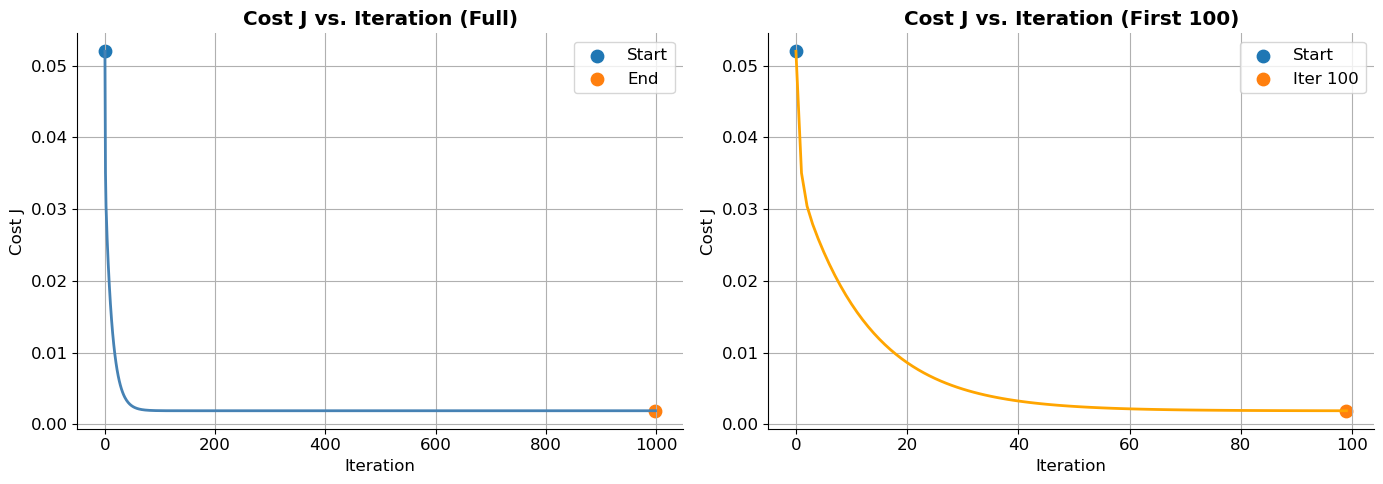

Reflect:
  1. Does the cost decrease smoothly?
  2. When does it mostly level off (converge)?
  3. What would the curve look like if α were too large?


In [13]:
# ✏️ Task 7 — Plot cost vs. iteration number

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Full cost curve ────────────────────────────────────────────
axes[0].set_title("Cost J vs. Iteration (Full)", fontweight='bold')
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Cost J")

# YOUR CODE  HERE — plot model.cost_history on axes[0]
# Hint: axes[0].plot(model.cost_history, color='steelblue', linewidth=2)
axes[0].plot(model.cost_history, color='steelblue', linewidth=2)
axes[0].grid(True)

# Highlight start and end points
axes[0].scatter(0, model.cost_history[0], s=80, label='Start')
axes[0].scatter(len(model.cost_history)-1, model.cost_history[-1], s=80, label='End')
axes[0].legend()


# ── Right: First 100 iterations (zoom in) ────────────────────────────
axes[1].set_title("Cost J vs. Iteration (First 100)", fontweight='bold')
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Cost J")

# YOUR CODE HERE — plot only the first 100 values of model.cost_history
# Hint: model.cost_history[:100]
axes[1].plot(model.cost_history[:100], color='orange', linewidth=2)
axes[1].grid(True)

# Highlight early drop
axes[1].scatter(0, model.cost_history[0], s=80, label='Start')
axes[1].scatter(99, model.cost_history[99], s=80, label='Iter 100')
axes[1].legend()

plt.tight_layout()
plt.show()

# ── Questions ────────────────────────────────────────────────────────
print("Reflect:")
print("  1. Does the cost decrease smoothly?")
print("  2. When does it mostly level off (converge)?")
print("  3. What would the curve look like if α were too large?")

---
## 🔮 Step 8 — Make Predictions & Unscale

Our model predicts **scaled salary** (0 to 1).  
We need to convert back to **real USD** using the inverse of Min-Max scaling:

$$\hat{y}_{\text{USD}} = \hat{y}_{\text{scaled}} \times (\text{sal\_max} - \text{sal\_min}) + \text{sal\_min}$$


In [14]:
# ── 📘 DEMO: How to unscale predictions ──────────────────────────────
# sal_min and sal_max were saved in Step 3
print(f"sal_min = {sal_min:,.0f},  sal_max = {sal_max:,.0f}")

# Example: if model predicts scaled_value = 0.6
example_scaled = 0.6
example_usd = example_scaled * (sal_max - sal_min) + sal_min
print(f"Scaled prediction 0.6 → ${example_usd:,.0f} USD")


sal_min = 30,000,  sal_max = 100,000
Scaled prediction 0.6 → $72,000 USD


In [15]:
# ✏️ Task 8 — Predict on test set, then unscale

# Step 1: Get scaled predictions on X_test
# YOUR CODE HERE
y_pred_scaled = model.predict(X_test)

# Step 2: Unscale predictions → real USD
# Formula: x_original = x_scaled * (max - min) + min
y_pred_usd = y_pred_scaled * (sal_max - sal_min) + sal_min

# Step 3: Unscale the true test labels → real USD
y_test_usd = y_test * (sal_max - sal_min) + sal_min

# ── Auto-check ───────────────────────────────────────────────────────
assert y_pred_scaled is not None, "y_pred_scaled is None — call model.predict()"
assert y_pred_usd is not None,    "y_pred_usd is None — unscale the prediction"
assert y_test_usd is not None,    "y_test_usd is None — unscale the labels"
print("✅ Predictions computed!")
print()
print("Sample predictions vs actuals (USD):")
for i in range(min(5, len(y_test_usd))):
    print(f"  Predicted: ${y_pred_usd[i]:>9,.0f}  |  Actual: ${y_test_usd[i]:>9,.0f}  |  Error: ${abs(y_pred_usd[i]-y_test_usd[i]):,.0f}")

✅ Predictions computed!

Sample predictions vs actuals (USD):
  Predicted: $   94,542  |  Actual: $   91,933  |  Error: $2,609
  Predicted: $   57,920  |  Actual: $   54,976  |  Error: $2,944
  Predicted: $   83,633  |  Actual: $   92,907  |  Error: $9,273
  Predicted: $   61,037  |  Actual: $   67,503  |  Error: $6,466
  Predicted: $   44,674  |  Actual: $   52,088  |  Error: $7,414


---
## 📏 Step 9 — Evaluate Your Model

### Three key metrics:

| Metric | Formula | What it tells you |
|--------|---------|-------------------|
| **MSE** | (1/m) Σ (ŷ−y)² | Average squared error (same units²) |
| **RMSE** | √MSE | Average error in original units (USD) |
| **R²** | 1 − SS_res/SS_tot | % of variance explained (1.0 = perfect) |

Where:
- SS_res = Σ(ŷ−y)²  (residual sum of squares)
- SS_tot = Σ(y−ȳ)²  (total sum of squares)


In [16]:
# ✏️ Task 9 — Compute MSE, RMSE, and R² manually (no sklearn yet!)

m_test = len(y_test_usd)

# ── MSE ───────────────────────────────────────────────────────────────
# YOUR CODE HERE
# mse = (1 / m_test) * np.sum( (y_pred_usd - y_test_usd) ** 2 )
mse = (1 / m_test) * np.sum((y_pred_usd - y_test_usd) ** 2)

# ── RMSE ──────────────────────────────────────────────────────────────
# YOUR CODE HERE
# rmse = np.sqrt(mse)
rmse = np.sqrt(mse)

# ── R² ────────────────────────────────────────────────────────────────
# SS_res = np.sum( (y_pred_usd - y_test_usd)**2 )
# SS_tot = np.sum( (y_test_usd - np.mean(y_test_usd))**2 )
# r2 = 1 - SS_res / SS_tot
# YOUR CODE HERE
SS_res = np.sum((y_pred_usd - y_test_usd) ** 2)
SS_tot = np.sum((y_test_usd - np.mean(y_test_usd)) ** 2)
r2 = 1 - SS_res / SS_tot


assert mse  is not None, "MSE is None — fill in the formula"
assert rmse is not None, "RMSE is None — take the sqrt of MSE"
assert r2   is not None, "R² is None — use the SS_res / SS_tot formula"

print("=" * 40)
print("  YOUR MODEL PERFORMANCE")
print("=" * 40)
print(f"  MSE  : {mse:>12,.2f}")
print(f"  RMSE : ${rmse:>10,.2f}  ← average error in USD")
print(f"  R²   : {r2:>12.4f}  ← closer to 1.0 = better")
print("=" * 40)

  YOUR MODEL PERFORMANCE
  MSE  : 34,066,795.47
  RMSE : $  5,836.68  ← average error in USD
  R²   :       0.9024  ← closer to 1.0 = better


C:\Users\junai\AppData\Local\Temp\ipykernel_10044\2559144066.py:57: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\junai\AppData\Local\Temp\ipykernel_10044\2559144066.py:57: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\junai\anaconda3\envs\ai_ml_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\junai\anaconda3\envs\ai_ml_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


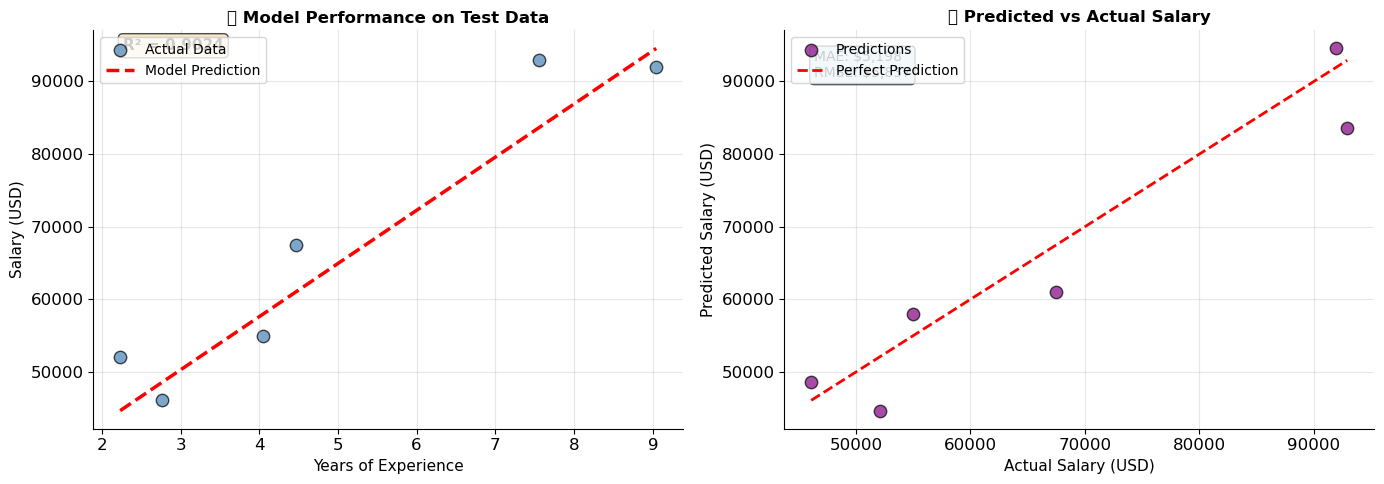


📊 MODEL PERFORMANCE SUMMARY
✅ R² Score:     0.9024  (Excellent!)
✅ MAE:          $5,197.87  (Avg prediction error)
✅ RMSE:         $5,836.68  (Std deviation of errors)
📈 Test samples: 6


In [17]:
# ✏️ Task 9.2 — Visualise predictions vs actuals

# First, make predictions on test data
y_pred_scaled = model.predict(X_test)  # Get predictions on scaled data
y_pred_usd = y_pred_scaled * (sal_max - sal_min) + sal_min  # Convert back to USD

# Unscale X_test for plotting
X_test_years = X_test * (exp_max - exp_min) + exp_min
y_test_usd = y_test * (sal_max - sal_min) + sal_min

# Sort for smooth line
sort_idx = np.argsort(X_test_years.flatten())
X_sorted = X_test_years.flatten()[sort_idx]
y_pred_sorted = y_pred_usd.flatten()[sort_idx]

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Test Data with Model Prediction ──────────────────────────────
axes[0].scatter(X_test_years, y_test_usd, color='steelblue', alpha=0.7,
                s=80, edgecolors='black', linewidth=1, label='Actual Data')
axes[0].plot(X_sorted, y_pred_sorted, color='red', linewidth=2.5,
             label='Model Prediction', linestyle='--')
axes[0].set_xlabel("Years of Experience", fontsize=11)
axes[0].set_ylabel("Salary (USD)", fontsize=11)
axes[0].set_title("📈 Model Performance on Test Data", fontsize=12, fontweight='bold')
axes[0].legend(loc='upper left', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Add R² score on plot
from sklearn.metrics import r2_score
r2 = r2_score(y_test_usd, y_pred_usd)
axes[0].text(0.05, 0.95, f'R² = {r2:.4f}', transform=axes[0].transAxes,
             fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# ── Right: Predicted vs Actual ────────────────────────────────────────
axes[1].scatter(y_test_usd, y_pred_usd, color='purple', alpha=0.7,
                s=80, edgecolors='black', linewidth=1, label='Predictions')
axes[1].plot([y_test_usd.min(), y_test_usd.max()],
             [y_test_usd.min(), y_test_usd.max()],
             'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel("Actual Salary (USD)", fontsize=11)
axes[1].set_ylabel("Predicted Salary (USD)", fontsize=11)
axes[1].set_title("🎯 Predicted vs Actual Salary", fontsize=12, fontweight='bold')
axes[1].legend(loc='upper left', fontsize=10)
axes[1].grid(True, alpha=0.3)

# Add error metrics on plot
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(y_test_usd, y_pred_usd)
rmse = np.sqrt(mean_squared_error(y_test_usd, y_pred_usd))
axes[1].text(0.05, 0.95, f'MAE: ${mae:,.0f}\nRMSE: ${rmse:,.0f}',
             transform=axes[1].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

plt.tight_layout()
plt.show()

# ── Statistics Output ──────────────────────────────────────────────────
print("\n" + "="*55)
print("📊 MODEL PERFORMANCE SUMMARY")
print("="*55)
print(f"✅ R² Score:     {r2:.4f}  {'(Excellent!)' if r2 > 0.8 else '(Good)' if r2 > 0.6 else '(Needs improvement)'}")
print(f"✅ MAE:          ${mae:,.2f}  (Avg prediction error)")
print(f"✅ RMSE:         ${rmse:,.2f}  (Std deviation of errors)")
print(f"📈 Test samples: {len(X_test)}")
print("="*55)

---
## 🔬 Step 10 — Compare with `sklearn` LinearRegression

Now we'll train sklearn's `LinearRegression` on the same data and compare.

> **sklearn** uses the **Normal Equation** (an analytical closed-form solution), not gradient descent.  
> The Normal Equation directly solves: **θ = (XᵀX)⁻¹ Xᵀy** in one step.  
> Your model uses iterative gradient descent — so results will be very similar but may differ slightly.


In [18]:
# ── Train sklearn's LinearRegression (the 'correct answer') ─────────

# sklearn expects 2D arrays for X
X_train_2d = X_train.reshape(-1, 1)
X_test_2d  = X_test.reshape(-1, 1)

sk_model = LinearRegression()
sk_model.fit(X_train_2d, y_train)

# sklearn predictions (scaled)
sk_pred_scaled = sk_model.predict(X_test_2d)

# Unscale → USD
sk_pred_usd = sk_pred_scaled * (sal_max - sal_min) + sal_min

sk_rmse = np.sqrt(mean_squared_error(y_test_usd, sk_pred_usd))
sk_r2   = r2_score(y_test_usd, sk_pred_usd)

print("=" * 50)
print("  SIDE-BY-SIDE COMPARISON")
print("=" * 50)
print(f"{'Metric':<12}  {'Your GD Model':>16}  {'sklearn':>16}")
print("-" * 50)
print(f"{'RMSE ($)':<12}  {rmse:>16,.2f}  {sk_rmse:>16,.2f}")
print(f"{'R²':<12}  {r2:>16.4f}  {sk_r2:>16.4f}")
print("=" * 50)

diff_r2 = abs(r2 - sk_r2)
print()
if diff_r2 < 0.01:
    print("✅ Excellent! Your model is within 1% R² of sklearn.")
elif diff_r2 < 0.05:
    print("⚠️  Close! Within 5% of sklearn. Try more iterations or a different α.")
else:
    print("❌ Large gap. Check your gradient formulas and cost history.")


  SIDE-BY-SIDE COMPARISON
Metric           Your GD Model           sklearn
--------------------------------------------------
RMSE ($)              5,836.68          5,836.68
R²                      0.9024            0.9024

✅ Excellent! Your model is within 1% R² of sklearn.


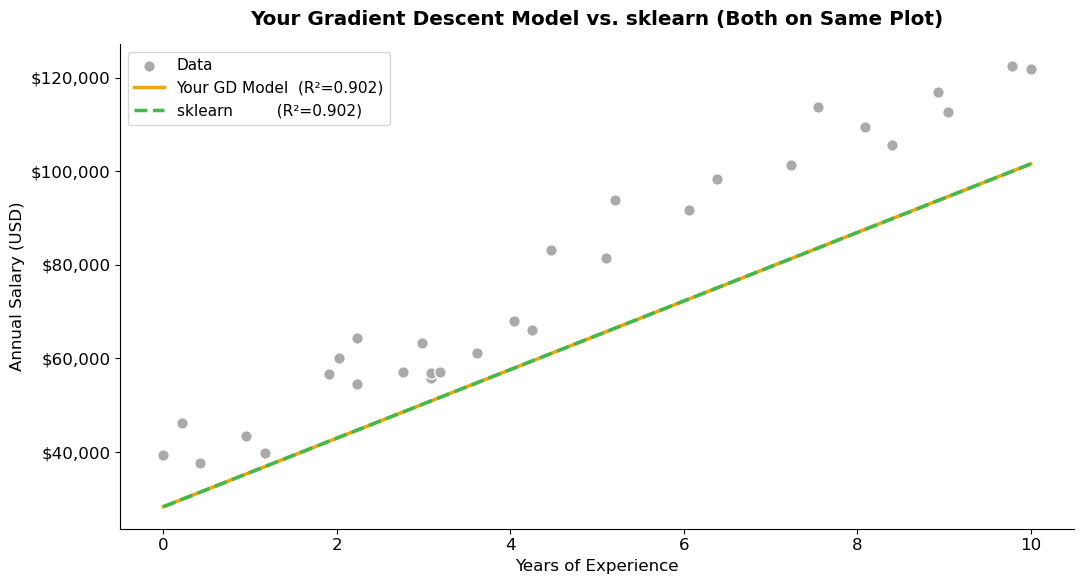

In [19]:
# ── Visual Comparison: Both regression lines on the same plot ───────────

# Unscale full dataset for plotting
X_all_years = x_scaled * (exp_max - exp_min) + exp_min

# Your model's prediction across full range
X_range_scaled = np.linspace(0, 1, 200)
X_range_years  = X_range_scaled * (exp_max - exp_min) + exp_min

your_line_usd  = model.predict(X_range_scaled)  * (sal_max - sal_min) + sal_min
sk_line_usd    = sk_model.predict(X_range_scaled.reshape(-1,1)) * (sal_max - sal_min) + sal_min

fig, ax = plt.subplots(figsize=(11, 6))
ax.set_title("Your Gradient Descent Model vs. sklearn (Both on Same Plot)", fontweight='bold', pad=14)
ax.set_xlabel("Years of Experience")
ax.set_ylabel("Annual Salary (USD)")

# All data points
ax.scatter(X_all_years, salary, color='#aaaaaa', edgecolors='white',
           s=70, zorder=3, label='Data')

# Your model
ax.plot(X_range_years, your_line_usd,
        color='#f0a500', linewidth=2.5, label=f'Your GD Model  (R²={r2:.3f})')

# sklearn
ax.plot(X_range_years, sk_line_usd,
        color='#3fb950', linewidth=2.5, linestyle='--', label=f'sklearn         (R²={sk_r2:.3f})')

ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()


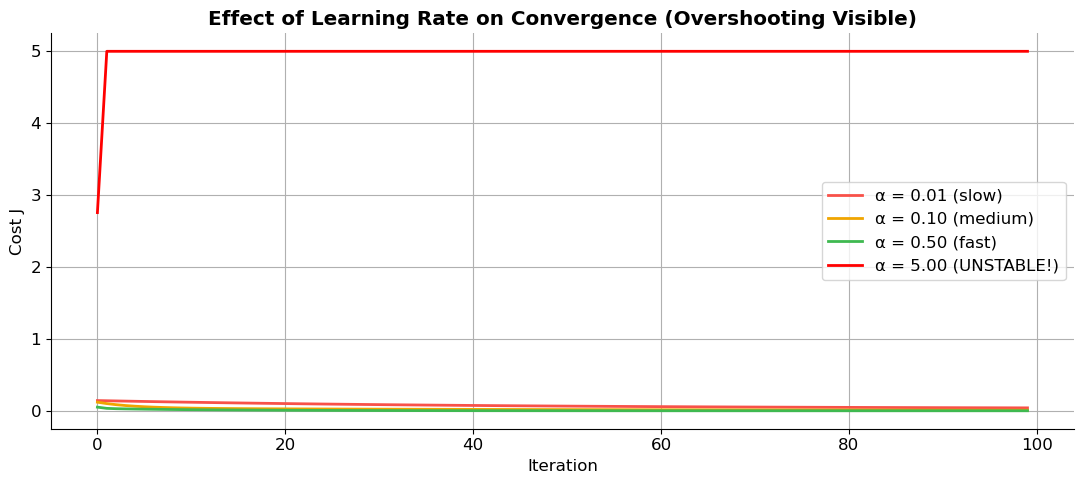

Observations:
  α = 0.01 → cost decreases slowly (too small)
  α = 0.10 → smooth and stable convergence
  α = 0.50 → fast convergence (best balance)
  α = 5.00 → CLEAR OVERSHOOTING (unstable, jumps/oscillates)


In [20]:
# ✏️ Task 10 — Experiment: Effect of Learning Rate
# Train 4 models with different learning rates and plot their cost curves

learning_rates = [0.01, 0.1, 0.5, 5]  # 5.0 will clearly overshoot
colors = ['#f85149', '#f0a500', '#3fb950', '#ff0000']
labels = ['α = 0.01 (slow)', 'α = 0.10 (medium)', 'α = 0.50 (fast)', 'α = 5.00 (UNSTABLE!)']

fig, ax = plt.subplots(figsize=(11, 5))
ax.set_title("Effect of Learning Rate on Convergence (Overshooting Visible)", fontweight='bold')
ax.set_xlabel("Iteration")
ax.set_ylabel("Cost J")

for lr, color, label in zip(learning_rates, colors, labels):
    exp_model = LinearRegressionGD(learning_rate=lr, n_iterations=100)  # fewer iterations to show instability early
    exp_model.fit(X_train, y_train)

    # If exploding values, clip for visualization so graph stays readable
    cost = np.array(exp_model.cost_history)
    cost = np.clip(cost, 0, 5)  # limit extreme spikes

    ax.plot(cost, color=color, linewidth=2, label=label)

ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

print("Observations:")
print("  α = 0.01 → cost decreases slowly (too small)")
print("  α = 0.10 → smooth and stable convergence")
print("  α = 0.50 → fast convergence (best balance)")
print("  α = 5.00 → CLEAR OVERSHOOTING (unstable, jumps/oscillates)")

---
## 🌟 Bonus Challenge (Optional)

### 1. Stochastic Gradient Descent

Modify your class (or create `SGDLinearRegression`) to use **stochastic** gradient descent — update parameters using **one random sample at a time** instead of the full batch.

Compare the cost curves of Batch GD vs SGD. Which is noisier?

### 2. Early Stopping

Add an `early_stopping` parameter to `__init__`. If the cost improvement between iterations is less than `tolerance = 1e-6`, stop training early and print how many iterations it actually took.

### 3. Mini-Batch Gradient Descent

Implement mini-batch GD with a configurable `batch_size` parameter.  
Test with `batch_size = 8` and compare with full-batch.


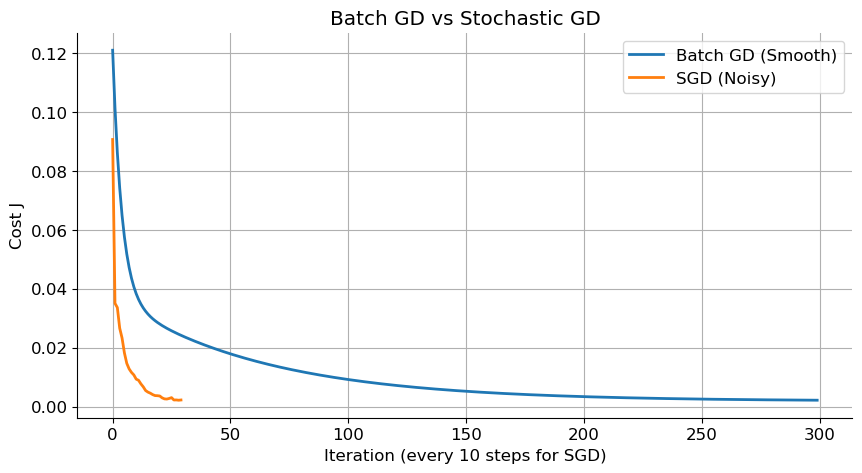

In [21]:
# 🌟 BONUS — Stochastic Gradient Descent class


class SGDLinearRegression:
    """Linear Regression with Stochastic Gradient Descent (1 sample per update)."""

    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.theta0 = 0.0
        self.theta1 = 0.0
        self.cost_history = []

    def fit(self, X, y):
        m = len(y)
        for i in range(self.n_iter):
            # Pick ONE random sample index
            idx = np.random.randint(0, m)
            xi  = X[idx]
            yi  = y[idx]

            # YOUR CODE HERE — compute prediction and error for just sample idx
            pred  = self.theta0 + self.theta1 * xi
            error = pred - yi

            # YOUR CODE HERE — gradient for 1 sample (no 1/m average needed)
            grad0 = error
            grad1 = error * xi

            # YOUR CODE HERE — simultaneous update
            temp0 = self.theta0 - self.lr * grad0
            temp1 = self.theta1 - self.lr * grad1

            self.theta0 = temp0
            self.theta1 = temp1

            # Record full batch cost every 10 steps (for comparison)
            if i % 10 == 0:
                full_cost = (1/(2*m)) * np.sum((self.theta0 + self.theta1*X - y)**2)
                self.cost_history.append(full_cost)

        return self


# ── Compare SGD vs Batch GD cost curves ──────────────────────────────
# YOUR CODE HERE — train both, plot side by side

# ── Compare SGD vs Batch GD cost curves ──────────────────────────────

# Batch Gradient Descent model
bgd_model = LinearRegressionGD(learning_rate=0.1, n_iterations=300)
bgd_model.fit(X_train, y_train)

# SGD model
sgd_model = SGDLinearRegression(learning_rate=0.1, n_iterations=300)
sgd_model.fit(X_train, y_train)

# Plot
plt.figure(figsize=(10, 5))

plt.plot(bgd_model.cost_history, label="Batch GD (Smooth)", linewidth=2)
plt.plot(sgd_model.cost_history, label="SGD (Noisy)", linewidth=2)

plt.title("Batch GD vs Stochastic GD")
plt.xlabel("Iteration (every 10 steps for SGD)")
plt.ylabel("Cost J")
plt.legend()
plt.grid(True)

plt.show()

---
## ✅ Summary — What You Built

Congratulations! Here's what you implemented from scratch:

| Component | Formula |
|---|---|
| **Hypothesis** | hθ(x) = θ₀ + θ₁x |
| **Cost** | J = (1/2m) Σ (hθ(xⁱ) − yⁱ)² |
| **Gradient θ₀** | ∂J/∂θ₀ = (1/m) Σ (hθ(xⁱ) − yⁱ) |
| **Gradient θ₁** | ∂J/∂θ₁ = (1/m) Σ (hθ(xⁱ) − yⁱ) · xⁱ |
| **Update rule** | θ := θ − α · ∂J/∂θ |

Your gradient descent model should achieve **R² ≥ 0.95** on this dataset — almost identical to sklearn's closed-form solution! 🎉

---
*This notebook was built to accompany the Linear Regression lecture. Keep it as a reference for future implementations.*
